In [1]:
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath('..'))

from src.optimization.microgrid import Microgrid

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16
})

In [4]:
results_dict = microgrid.optimize(start_date='2018-07-01', end_date='2018-07-02')
print("Max demand:", results_dict['cost_breakdown']['max_demand'])
print("On-peak demand:", results_dict['cost_breakdown']['on_peak_demand'])
print("Max demand charge:", results_dict['cost_breakdown']['max_demand'] * 15.38)
print("On-peak demand charge:", results_dict['cost_breakdown']['on_peak_demand'] * 3.05)
print("Max grid import:", results_dict['grid_import'].max())
print("Min grid import:", results_dict['grid_import'].min())
print("Max battery power:", results_dict['battery_power'].max())
print("Min battery power:", results_dict['battery_power'].min())
import pandas as pd
import numpy as np
timestamps = results_dict['timestamps']
timestamps_pd = [pd.Timestamp(ts, unit='s') for ts in timestamps]
from src.optimization.pricing import get_tou_period
on_peak_mask = np.array([get_tou_period(ts) == 'on_peak' for ts in timestamps_pd])
print("On-peak mask:", on_peak_mask)
print("On-peak grid import values:", results_dict['grid_import'][on_peak_mask])
print("Max on-peak:", results_dict['grid_import'][on_peak_mask].max() if np.any(on_peak_mask) else "No on-peak hours")
for ts in timestamps_pd:
    print(ts, "→", get_tou_period(ts))

Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
Max demand: 94.63968384738928
On-peak demand: 1.6268475120891593e-06
Max demand charge: 1455.5583375728472
On-peak demand charge: 4.961884911871936e-06
Max grid import: 94.63968384738928
Min grid import: 1.0758773467131835e-06
Max battery power: 95.5344987073424
Min battery power: -53.27143384417797
On-peak mask: [False False False False False False False False False False False False
 False False False False  True  True  True  True  True False False False]
On-peak grid import values: [1.62684751e-06 1.52917345e-06 1.46567654e-06 1.29265761e-06
 1.07587735e-06]
Max on-peak: 1.6268475120891593e-06
2018-07-01 00:00:00 → super_off_peak
2018-07-01 01:00:00 → super_off_peak
2018-07-01 02:00:00 → super_off_peak
2018-07-01 03:00:00 → super_off_peak
2018-07-01 04:00:00 → super_off_peak
2018-07-01 05:00:00 → super_off_peak
2018-07-01 06:00:00 → super_off_peak
2018-07-01 07:00:00 → super_off_peak
2018-07-01 08:00:00 → super_off_p

In [2]:
# creates a microgrid object with specified components that holds data and parameters
microgrid = Microgrid(
    loads=['StudentServices'], 
    pv_generators=['BioEngineeringPV'], 
    batteries=['BatteryStorage'] 
)

In [5]:

print("Loads:", microgrid.loads[0].name)
print("PV Generators:", microgrid.pv_generators[0].name)
print("Batteries:", microgrid.batteries[0].name)
# load data for the components
print("total load:", microgrid.get_total_load())
print("total PV generation:", microgrid.get_total_pv_generation())
print("total battery capacity:", microgrid.get_total_battery_storage())
print("number of time steps:", microgrid.get_total_pv_generation().shape[0])


Loads: StudentServices
PV Generators: BioEngineeringPV
Batteries: BatteryStorage
total load: [95.5515  94.317   95.8335  ... 86.87075 85.92175 81.11675]
total PV generation: [ 5.273    8.9065  17.85175 ...  0.07025  0.0705   0.067  ]
total battery capacity: (2500, 5000)
number of time steps: 44776


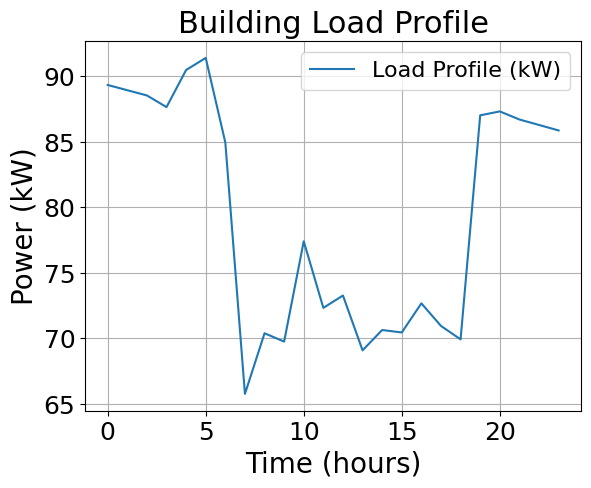

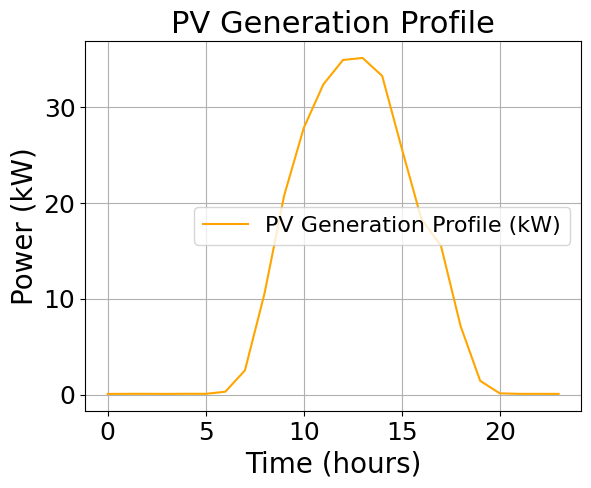

In [4]:

load_profile = microgrid.loads[0].get_load_profile('2016-07-16', '2016-07-17')  # kW
T = len(load_profile)

plt.figure()
plt.plot(range(T), load_profile, label='Load Profile (kW)')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Building Load Profile')
plt.legend()
plt.grid()
plt.show()

pv_profile = microgrid.pv_generators[0].get_generation_profile('2016-07-16', '2016-07-17')  # kW

plt.figure()
plt.plot(range(T), pv_profile, label='PV Generation Profile (kW)', color='orange')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV Generation Profile')
plt.legend()
plt.grid()
plt.show()




In [6]:
results_dict = microgrid.optimize(start_date='2016-07-16', end_date='2016-07-17')
print("Timestamps:", pd.to_datetime(results_dict['timestamps'], unit='s'))


Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
Timestamps: DatetimeIndex(['2016-07-16 00:00:00', '2016-07-16 01:00:00',
               '2016-07-16 02:00:00', '2016-07-16 03:00:00',
               '2016-07-16 04:00:00', '2016-07-16 05:00:00',
               '2016-07-16 06:00:00', '2016-07-16 07:00:00',
               '2016-07-16 08:00:00', '2016-07-16 09:00:00',
               '2016-07-16 10:00:00', '2016-07-16 11:00:00',
               '2016-07-16 12:00:00', '2016-07-16 13:00:00',
               '2016-07-16 14:00:00', '2016-07-16 15:00:00',
               '2016-07-16 16:00:00', '2016-07-16 17:00:00',
               '2016-07-16 18:00:00', '2016-07-16 19:00:00',
               '2016-07-16 20:00:00', '2016-07-16 21:00:00',
               '2016-07-16 22:00:00', '2016-07-16 23:00:00'],
              dtype='datetime64[ns]', freq=None)


In [6]:
print("Grid Import (kW):", results_dict['grid_import'])

Grid Import (kW): [68.35632291 68.35632291 68.35632291 68.35632291 68.35632291 68.35632291
 68.35632291 68.35632291 68.35632292 68.35632292 68.35632292 68.35632292
 68.35632292 68.35632292 68.35632292 68.35632292 68.35632292 68.35632292
 68.35632292 68.35632291 68.35632291 68.35632291 68.35632291 68.35632291]


In [7]:
print("SOC", results_dict['soc'])

SOC [2500.         2519.86965573 2539.35004896 2558.45091719 2576.71388543
 2597.65704116 2619.47870939 2634.96007762 2630.10242085 2622.00407658
 2603.60535731 2585.77070054 2558.78326876 2530.27607448 2497.58769271
 2468.15306093 2445.74177916 2432.42389738 2420.13890311 2414.83379634
 2431.20673957 2449.1046703  2466.46656354 2483.42921927 2500.        ]


In [8]:
print("cost breakdown:", results_dict['cost_breakdown'])

cost breakdown: {'total_cost': np.float64(1249.8270083198518), 'energy_charges': np.float64(198.50676175), 'demand_charges': np.float64(1051.3202465698516), 'max_demand': np.float64(68.35632292391753), 'on_peak_demand': 0.0}


In [9]:
print("total emissions (kg CO2):", results_dict['total_emissions_gco2'])

total emissions (kg CO2): 444779.82825300004



Running objective: cost ...
Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
  Status       : optimal
  Total Cost   : $1249.83
  Total Emissions: 444779.8 gCO2e

Running objective: emissions ...
Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
  Status       : optimal
  Total Cost   : $1461.21
  Total Emissions: 444779.8 gCO2e

Running objective: weighted ...
Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
  Status       : optimal
  Total Cost   : $1249.83
  Total Emissions: 444779.8 gCO2e


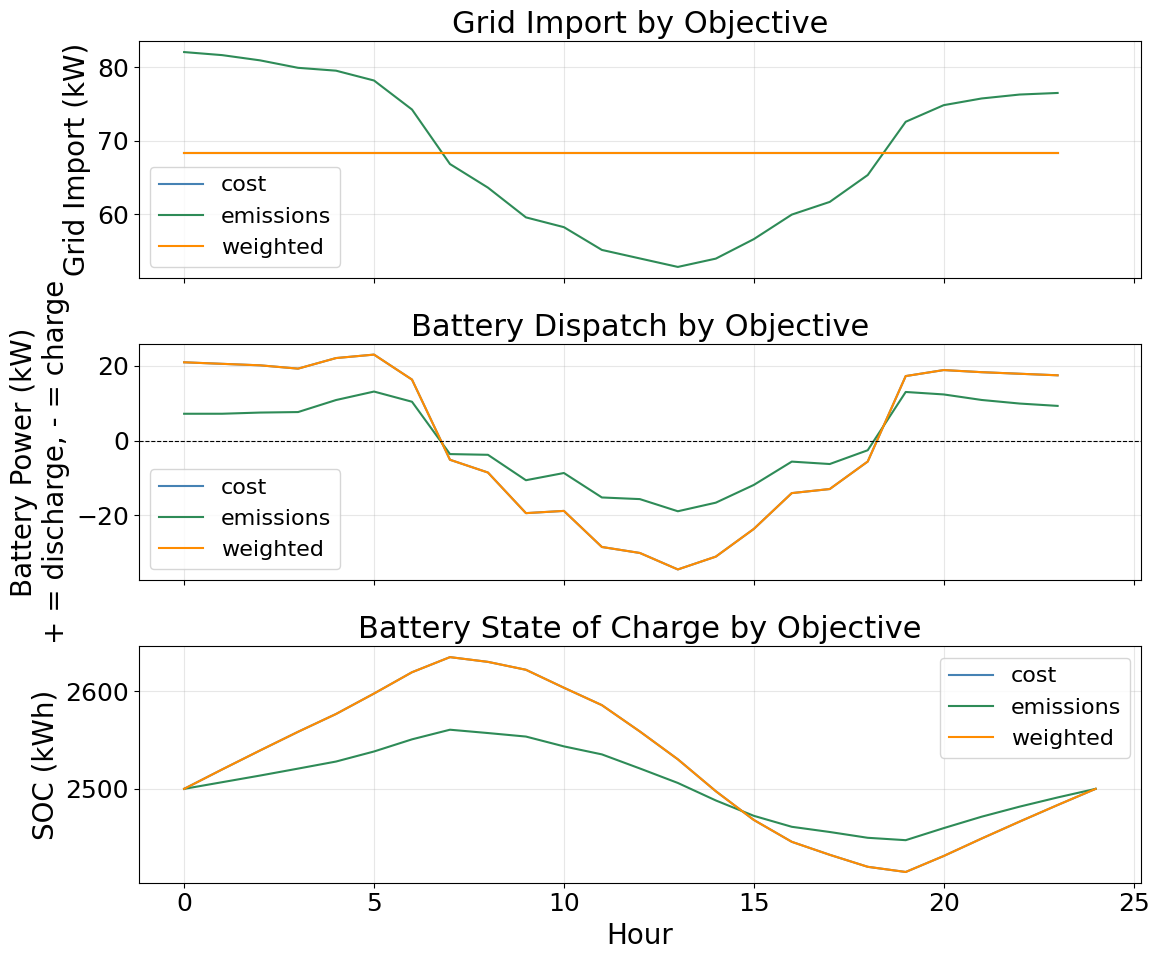


── Summary ─────────────────────────────────────────────────────
Objective      Total Cost ($)  Emissions (gCO2e)
------------------------------------------------
cost                  1249.83           444779.8
emissions             1461.21           444779.8
weighted              1249.83           444779.8


In [12]:
START = '2016-07-16'
END   = '2016-07-17'

LOADS       = ['StudentServices']               # adjust to your asset names in DATASETS
PV          = ['BioEngineeringPV']               # set to None if no PV
BATTERIES   = ['BatteryStorage']         # set to None if no battery

mg = Microgrid(loads=LOADS, pv_generators=PV, batteries=BATTERIES)

results = {}

for objective in ['cost', 'emissions', 'weighted']:
    print(f"\nRunning objective: {objective} ...")
    results[objective] = mg.optimize(
        start_date=START,
        end_date=END,
        objective_type=objective,
        round_trip_efficiency=0.95,
        include_soc_penalty=True,
        soc_min=0.20,
        soc_max=0.80,
    )
    r = results[objective]
    print(f"  Status       : {r['status']}")
    print(f"  Total Cost   : ${r['cost_breakdown']['total_cost']:.2f}")
    print(f"  Total Emissions: {r['total_emissions_gco2']:.1f} gCO2e")

# ── Plot comparison ─────────────────────────────────────────────────────────
hours = np.arange(24)
timestamps_hr = pd.to_datetime(results['cost']['timestamps'], unit='s').hour

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colors = {'cost': 'steelblue', 'emissions': 'seagreen', 'weighted': 'darkorange'}
ax = axes[0]
for obj, r in results.items():
    ax.plot(hours, r['grid_import'], label=obj, color=colors[obj])
ax.set_ylabel('Grid Import (kW)')
ax.set_title('Grid Import by Objective')
ax.legend()
ax.grid(True, alpha=0.3)

# Battery power per objective
ax = axes[1]
for obj, r in results.items():
    ax.plot(hours, r['battery_power'], label=obj, color=colors[obj])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Battery Power (kW)\n+ = discharge, - = charge')
ax.set_title('Battery Dispatch by Objective')
ax.legend()
ax.grid(True, alpha=0.3)

# SOC per objective
ax = axes[2]
for obj, r in results.items():
    ax.plot(r['soc'], label=obj, color=colors[obj])
ax.set_ylabel('SOC (kWh)')
ax.set_xlabel('Hour')
ax.set_title('Battery State of Charge by Objective')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n── Summary ─────────────────────────────────────────────────────")
print(f"{'Objective':<12} {'Total Cost ($)':>16} {'Emissions (gCO2e)':>18}")
print("-" * 48)
for obj, r in results.items():
    cost = r['cost_breakdown']['total_cost']
    emissions = r['total_emissions_gco2']
    print(f"{obj:<12} {cost:>16.2f} {emissions:>18.1f}")